<a href="https://colab.research.google.com/github/LeEvan8/Proj-genesis/blob/main/Group_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MME2232 Data Analytics Assignment
**Group 15 Members and Student No.:**

Joy Lim Yong Xin (2402528)

Rachel Choo Ying Qian (2402379)


---



**Authorship Labeling**:
Both members have contributed equally.

#0. Load Common Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
%matplotlib inline
from matplotlib import pyplot
from sklearn.model_selection import train_test_split

# 1. Loading Data


In [ ]:
df = pd.read_csv("/content/DS_D.csv")

# 2. Checking Data Characteristics
Before cleaning, data is loaded to get an initial feel of how the data looks like with the use of head, tail, columns, shape and info methods to diagnose data.

In [ ]:
df.head() # showing the first 5 rows

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
df.tail() # showing the last 5 rows

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
9995,9996,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H,299.0,308.7,1408,48.5,25,0,No Failure
9999,10000,M,299.0,308.7,1500,40.2,30,0,No Failure


In [ ]:
df.columns # column names of features

Index(['Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type'],
      dtype='object')

In [ ]:
# Extracting the numeric and categorical features in
# The separate data frames for easier manipulation and vizualisation.
numeric = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]]

categorical = df[[
       'Failure Type',
       'Target',
       'Type'
]]

In [ ]:
list(df) #List of column headers:

['Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type']

In [ ]:
df.shape # Shape gives the number of rows and columns in a tuble

(10000, 9)

In [ ]:
# Simple visualisation by surveying data labels (column heading name) in dataset.
# There are 2 categorical data, namely the 'Target' and 'Failure Type'.

# 1. Inspecting the amount of each target type
df["Target"].value_counts()

,count
Target,
0,9661
1,339


<Figure size 1000x1000 with 0 Axes>

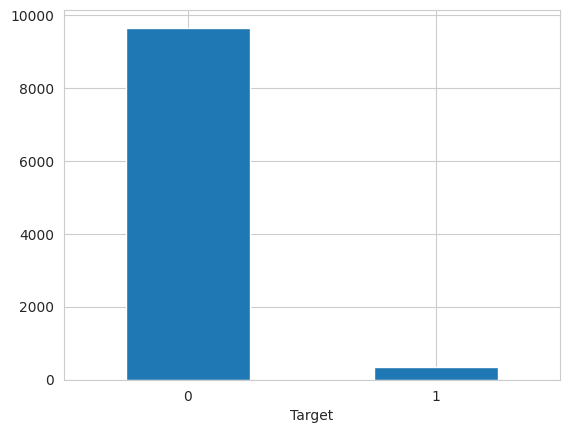

<Figure size 1000x1000 with 0 Axes>

In [ ]:
# Plotting a graph for better visualisation for target count
barlist = df['Target'].value_counts().plot(kind='bar', rot=0) # rot is rotation of text
plt.figure(figsize=(10,10))

**Insight**

From the given dataset D, it is important to note that Target Value '0' indicates that there is no failure while Target Value '1' indicates that there is failure.

The total measured data stands at 10,000. From the initial inspection from the count and bar graph, it is evident that there are significantly more '0' data than '1' data. About 96.6% (9661) were '0' data while 3.4% (339) were '1' data.

Variance between each target value is extremely high.

In [ ]:
# Inspecting the amount of entries for each failure type
df["Failure Type"].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


<Figure size 1000x1000 with 0 Axes>

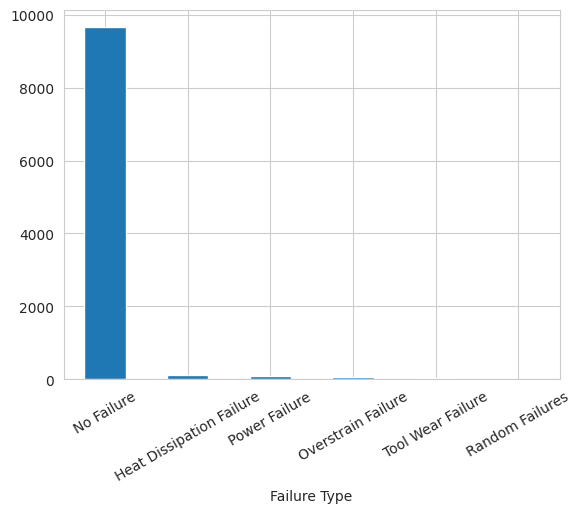

<Figure size 1000x1000 with 0 Axes>

In [ ]:
# Plotting a bar graph for better visualisation for of the spread of data for 'Failure Type' output parameter.
barlist = df['Failure Type'].value_counts().plot(kind='bar', rot=30) # rot is rotation of text
plt.figure(figsize=(10,10))

**Insight**

The total measured data stands at 10,000. From the initial inspection about 96.52% (9652), 1.12% (112), 0.95% (95), 0.78% (78), 0.45% (45), 0.18% (18) were categorised as 'No Failure', 'Heat Dissipation Failure', 'Power Failure', 'Overstrain Failure', 'Tool Wear Failure', and 'Random Failures'.

The variance between the failure datas with non failure datas of each data entry is extremely high.

# 2. Checking for Missing Data

In [ ]:
# Generate preview of entries with null values
if df.isnull().any(axis=None):
    print("\nPreview of data with null values")
    print(df[df.isnull().any(axis=1)].head(3))
    missingno.matrix(df)
    plt.show()

# No output returned as the dataset does not have any missing values. This eliminates the need for removal of missing data.

# 3. Checking for Duplicated Data

In [ ]:
# To check the presence of any duplication within the 'Target' column:
df["Target"].duplicated()

,Target
0,False
1,True
2,True
3,True
4,True
...,...
9995,True
9996,True
9997,True
9998,True


In [ ]:
# To check the presence of any duplication within the 'Failure Type' column:
df["Failure Type"].duplicated()

,Failure Type
0,False
1,True
2,True
3,True
4,True
...,...
9995,True
9996,True
9997,True
9998,True


In [ ]:
# Check for duplicate entries
if len(df[df.duplicated()]) > 0:
    print("Number of duplicated entries: ", len(df[df.duplicated()]))
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head())
else:
    print("No duplicated entries found")

No duplicated entries found


In [ ]:
# Categorise Target type's features as it is our target

Failed_type = df[df["Target"].astype(int)=='1']
Approved_type = df[df["Target"].astype(int)=='0']

In [ ]:
# Categorise Failure type's features as it is our target

No_failure_type = df[df["Failure Type"]=='No Failure']
Power_Failure_type = df[df["Failure Type"]=='Power Failure']
Tool_Wear_Failure_type = df[df["Failure Type"]=='Tool Wear Failure']
Overstrain_Failure_type = df[df["Failure Type"]=='Overstrain Failure']
Heat_Dissipation_Failure_type = df[df["Failure Type"]=='Heat Dissipation Failure']
Random_Failure_type = df[df["Failure Type"]=='Random Failures']

# 4. Univariate Analysis



# 4.1 Histogram
Histogram is used to show the distribution of the variables of interest for a holisyic view of all variables for better understanding.  

The x axis represents the given values and the y axis represents their frequencies.

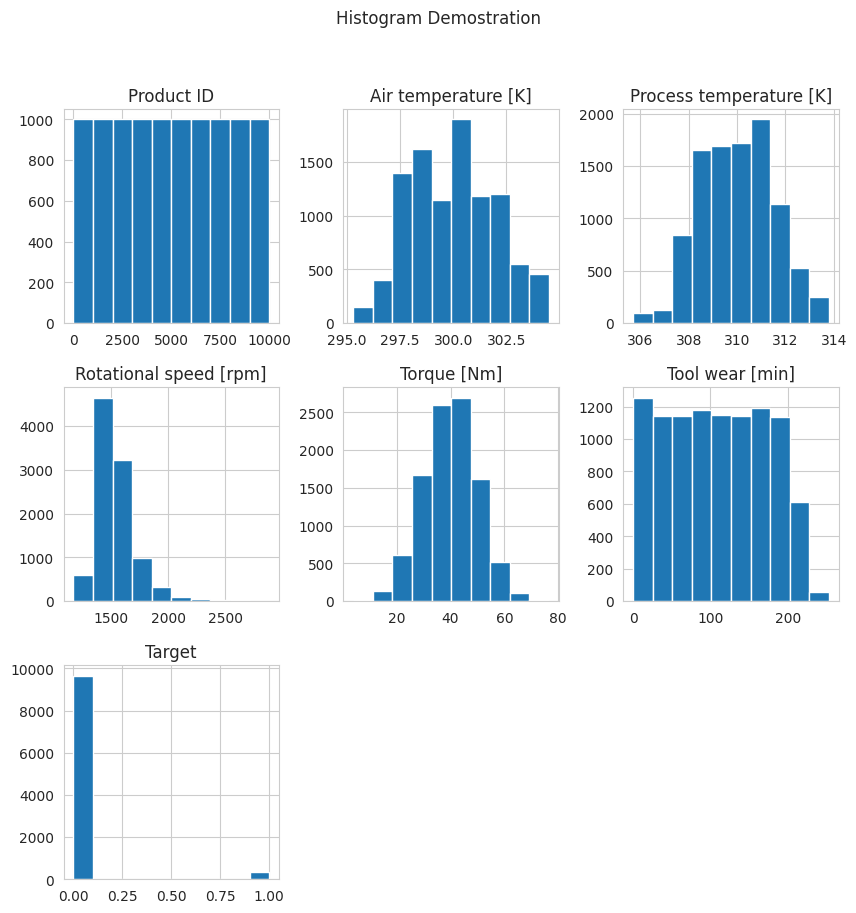

In [ ]:
# Visualise spread of parameters
df.hist(figsize=[10,10])
plt.suptitle("Histogram Demostration")
plt.show()

**Insight**

After observing the histograms for all input features, it can be said that:
1. **Product ID**: The raw data is relatively distributed across the graph.
2. **Torque [Nm]**: The raw data is quite centrally distributed, so may not possess any outliers.
3. **Air temperature [K], Tool wear [min], Process temperature [K]**: The raw data seems randomly distributed, may possess outliers.
4. **Rotational speed [rpm]**: The raw data is quite distubuted to the left, may possess outliers.
5. **Target**: The raw data has outliers.

This is just a first feel of the data.

# 5. Bi-Variate Analysis
It takes place between two features to explore the relationship between the two variables, covering their association, strength, the presence differences if any and  significants.

# 5.1 Heat Map







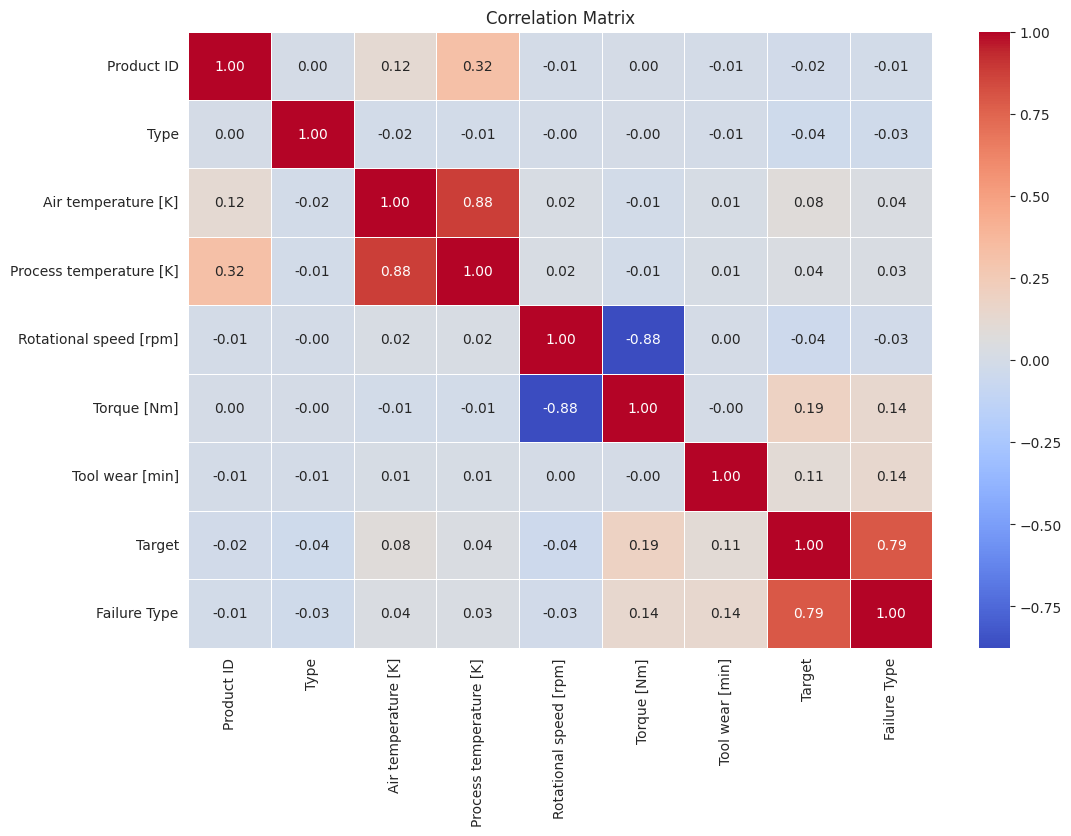

In [ ]:
df_corr = df.copy() # Create a copy for correlation
df_corr['Failure Type'] = df_corr['Failure Type'].map({
    'No Failure': 0,
    'Heat Dissipation Failure': 1,
    'Power Failure': 2,
    'Overstrain Failure': 3,
    'Tool Wear Failure': 4,
    'Random Failures': 5
})

df_corr['Type'] = df_corr['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Compute correlation matrix (for numeric columns only)
corr = df_corr.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

**Insight**

From the correlation matrix above, it can be observed that high correlation exists on **Process temperature [K]** on **Torque** at 0.88, indicating an extremely strong mechanical relationship where as rotational speeds increases, torque decreases significantly and vice versa. This reflects the fundamental power relationship in machines where Power = Torque x Speed. Another strong correlation is **Air Temperature [K]** and **Process Temperature [K]** with a correlation of 0.88. This means process temperature follows closely with air temperature. The process cooling system may be inadequate or envinronmental temperature heavily influences process temperature. In contrast, a strong negative correlation exists on **Torque [Nm]** and **Rotational speed [rpm]** at -0.88. This indicates an inversely proportional relationship where as **Rotational Speed** increases, **Torque** decreases significantly. Likewise, when **Torque** increases, **Rotational Speed** decreases significantly.

**Target** and **Failure Type** has a strong correlation of 0.79, suggesting when a failure occurs, the failure type is strongly predictable from the overall failure signal.

This heat map tells us in feature selection for model building, Torque, Rotational Speed and Tool Wear should be kept while Product ID and Type should be removed as they do not provide predictive values.

#5.2 Correlation Matrix
Correlation Matrix shows the correlation coefficient between every pair of numerical values in the dataset. The correlation coefficient is a value between -1 and 1 that measures the strength and the direction of a linear relationship between two variables. It is useful to summarise and highlight the level of correlation between the variables with different colour intensities.


*   +1: represents a perfect positive correlation
*   0: represents no linear correlation
*   -1: represents a perfect negative correlation

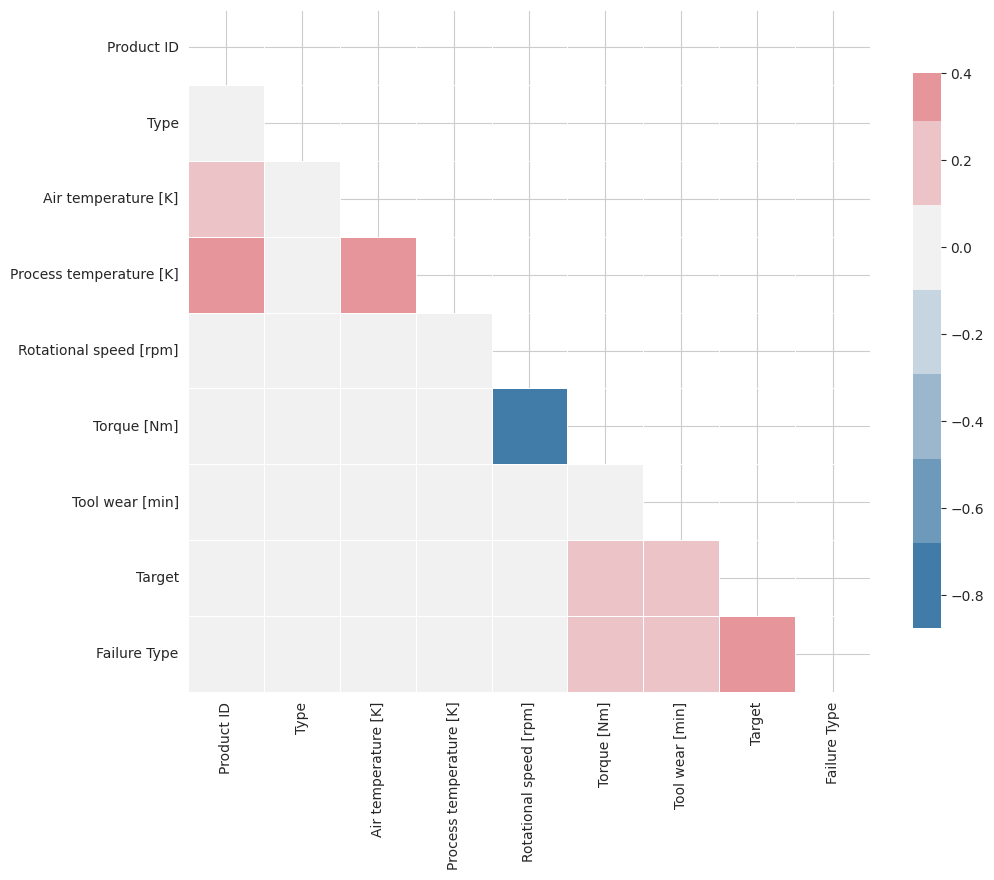

In [ ]:
df_corr_heatmap = df.copy()
df_corr_heatmap['Failure Type'] = df_corr_heatmap['Failure Type'].map({
    'No Failure': 0,
    'Heat Dissipation Failure': 1,
    'Power Failure': 2,
    'Overstrain Failure': 3,
    'Tool Wear Failure': 4,
    'Random Failures': 5
})

df_corr_heatmap['Type'] = df_corr_heatmap['Type'].map({'L': 0, 'M': 1, 'H': 2})

corr =  df_corr_heatmap.corr() # compute correlation on the copied dataframe
# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True
# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(240, 10, n=9)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.4, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.show()

**Insight**


**Correlation with the 'Target' output parameter**

*  Torque and Tool Wear which have been highlighted in red, indicating a strong correlation, have the highest correlation with Target. This tells us as tool wear increases, failure probability increases significantly. Higher torque values are also strong associated with fialures.

**Correlation with the 'Failure Type' output parameter**
*   There is a high positive correlation with Torque and Rotational Speed and a high posistive correlation with Process Temperature and Air Temperature.


From the correlation heat map, high correlation exists on **Process temperature [K]** on **Air temperature [K]** and on **Product ID** respectively as well as **Failure type** on **Target** at 0.4. In contrast, a strong negative correlation exists on Torque [Nm] and Rotational speed [rpm]. Additionally, Target and Failure type has a high correlation with Torque [Nm] and Tool wear [min] at 0.2.



# 5.2 Scatterplot
Scatterplot is a useful tool to create a visual representation between two numerical variables before fitting a regression model to inspect the potential linear correlation. In this case, graphs were plotted for the two pairs parameters, which we have identified to have strong and weak correlation, for specific model training analysis.

# 5.2.1 Scatterplot for Target

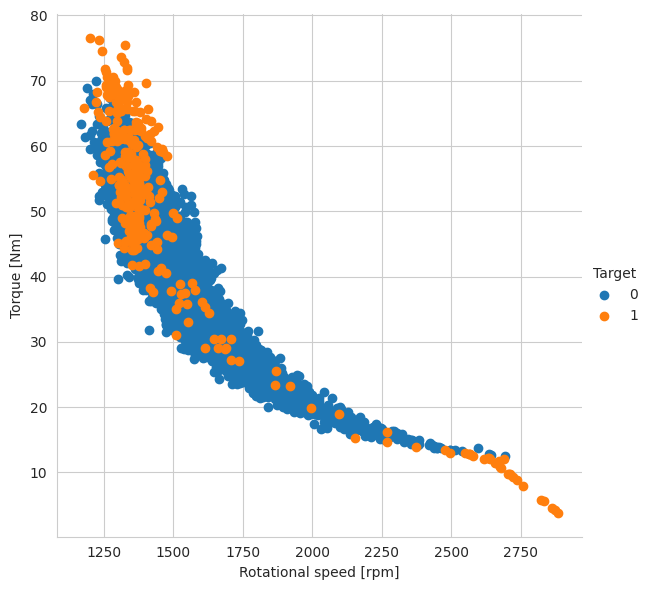

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df, hue = "Target" , height = 6).map(plt.scatter,"Rotational speed [rpm]","Torque [Nm]").add_legend()
plt.show()

**Insight**

To recap, target value '0' indicates that there is no failure while target value '1' indicates that there is failure.

For Target = 0 (no failure points), they are concentrated along the entire diagonal operating line, representing the normal operation across all rotational speed-torque combinations.

For Target = 1 (failure points), they are not randomly distributed, are concentratred at the extreme ends of the operating range; in high torque of 30Nm to 70Nm, low speed regions of 1250rpm to 1500rpm and high speed of 2500rpm to 2750rpm, low torque regions of 5Nm to 15Nm.


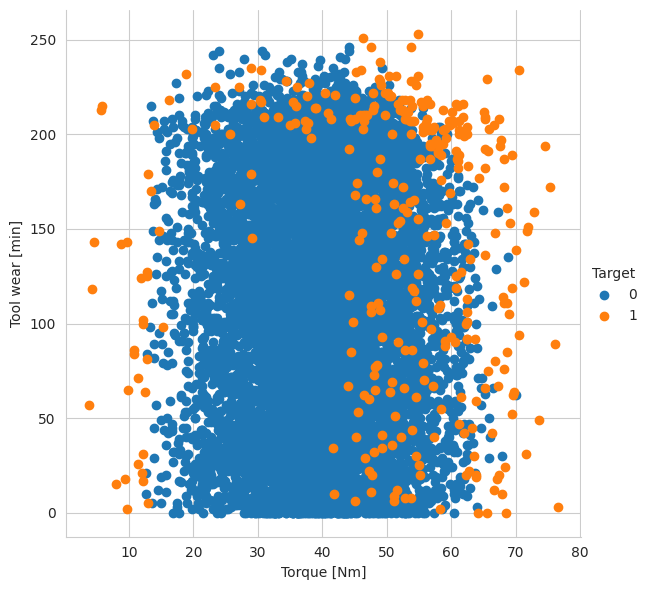

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df, hue = "Target" , height = 6).map(plt.scatter,"Torque [Nm]","Tool wear [min]").add_legend()
plt.show()

**Insight**

The scatter plot shows a non random, patterned distribution, showing a rather parabolic distribution between these two parameters, indicating a significant relationship between torque levels and machine failures.


*   Failure clustering at specific torque ranges, where failures are not evently distributed across all torque levels. There are specific torque ranges where failures cluster more densely, suggesting that there are critical tresholds where failure probability increases dramatically.
*   At some torque levels, both failures and normal operations are observed, indicating torque alone is not sufficient to perfectly predict failure.

At low torque range, there are possibly mostly Target = 0, indicating safe operations. At mid torque range, there arer mixed results with some failure clustering. At high torque range, there are possibly concentrated failure areas where target=1.

This suggests there are likely operational limits where exceeding certain torque levels dramatically increases failure risk. It is a critical feature that should be included.


# 5.2.2 Scatterplot for Failure Type

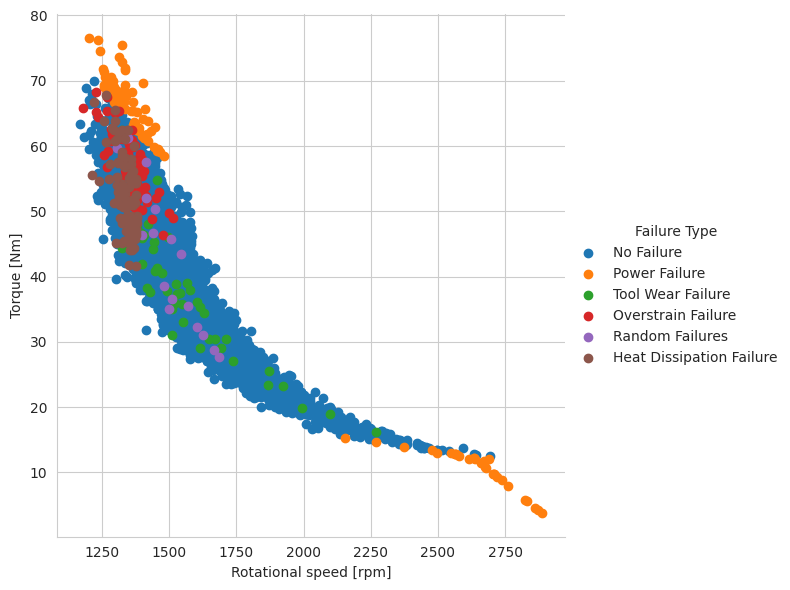

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df.astype({'Failure Type': str}), hue = "Failure Type" , height = 6).map(plt.scatter,"Rotational speed [rpm]","Torque [Nm]").add_legend()
plt.show()

**Insight**

From the scatterplot, the datasets are generally spread out for all failure types at first glance. After further inspection, speicfic failure types can be observed at the different torque and rotational speeds.

**Power Failures:**
There is a clutter at low rotational speeds of 1250rpm to 1500rpm and high torque regions of 60Nm to 78Nm. As well as clutter at low torque values of 5Nm to 15Nm and high rotational speeds of 2500rpm to 2750rpm, suggesting that there should be a balance between torque and rotational speed to prevent failure from occuring.

**Tool Wear Failures:**
They are scattered in speicifcal operational zones, suggesting they may be less dependent on the rotational speed-torque relationship and more on cumulative usage.

**Overstrain Failures:**
They are cluttered in the upper torque regions of 50Nm to 70Nm and lower rotational speeds of 1250rpm to 1500rpm, suggesting failure occurs at high mechanical stress conditions where both torque and rotational speeds are elevated. The combination of high load and high speeds creates mechanical overstress.

**Random Failures:**
Oberved to be scattered across low to medium rotational speeds of 1250rpm to 1700rpm and medium to high torque levels of 28Nm to 65Nm.

**Heat Dissipation Failure:**
Occurs at medium to high torque levels of 40Nm to 70Nm and low rotational speeds of 1250min to 1400min. This suggests failure is driven by rotational speeds, may be due to friction or heat generation, rather than just torque. High speeds generate heat that the system cannot dissipate effectively.

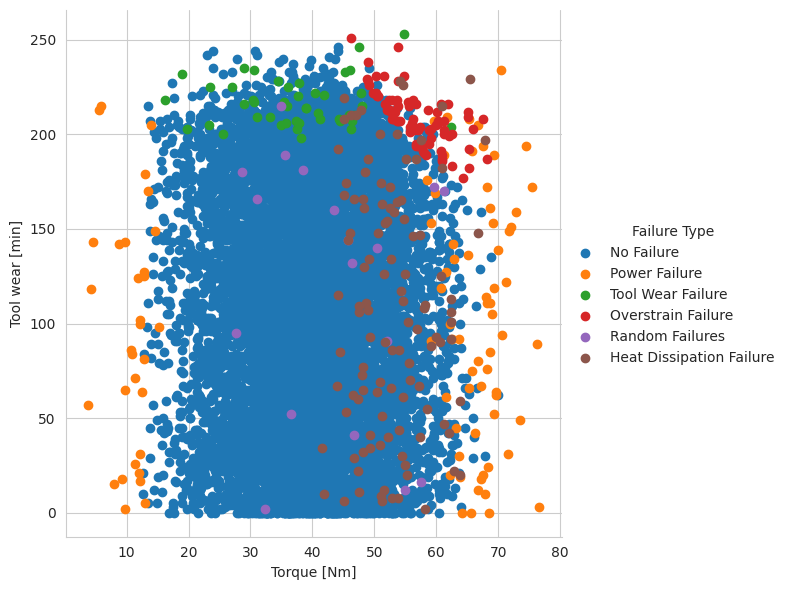

In [ ]:
sns.set_style("whitegrid")
sns.FacetGrid(df.astype({'Failure Type': str}), hue = "Failure Type" , height = 6).map(plt.scatter,"Torque [Nm]","Tool wear [min]").add_legend()
plt.show()

**Insight**

With this scatter plot, a more detailed and informative visualisation of the respective failure types can be observed.

**Tool Wear Failure:**
Tool wear failure type can be observed primarily in the upper curve, between 20Nm to 50Nm and 200min to 250min. This failure occurs when both torque stress and tool degradation are high simultaneously.

**Heat Dissipation Failure:**
Concentrated in the medium to high torque ranges, between 40Nm to 60Nm across various tool wear levels. This indicates the failure is more directly related to torque/ load rather than tool age.

**Overstrain Failure:**
Concentrated in the high torque regions between 50Nm to 70Nm and a high tool wear levels between 180min to 225min. This is an acute mechanical overload failure, not related to gradual wear.

**Power Failure:**
Concentrated across various tool wear levels but observed only at low torque regions and high torque regions of around 10Nm and 60Nm to 70Nm.

**Random Failures:**
They are scattered throughout varous tool wear values and torque values without cluttering.

# 6.1 Data Types and Conversion Method
Converting the parameters that are non numerical data type to categorical data type.

# 6.1.1 Converting 'Target' to Categorical Dtype

In [ ]:
df['Target'] = df['Target'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Product ID               10000 non-null  int64   
 1   Type                     10000 non-null  object  
 2   Air temperature [K]      10000 non-null  float64 
 3   Process temperature [K]  10000 non-null  float64 
 4   Rotational speed [rpm]   10000 non-null  int64   
 5   Torque [Nm]              10000 non-null  float64 
 6   Tool wear [min]          10000 non-null  int64   
 7   Target                   10000 non-null  category
 8   Failure Type             10000 non-null  object  
dtypes: category(1), float64(3), int64(3), object(2)
memory usage: 635.0+ KB


# 6.1.2 Converting 'Failure Type' to Categorical Dtype



In [ ]:
df['Failure Type'] = df['Failure Type'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Product ID               10000 non-null  int64   
 1   Type                     10000 non-null  object  
 2   Air temperature [K]      10000 non-null  float64 
 3   Process temperature [K]  10000 non-null  float64 
 4   Rotational speed [rpm]   10000 non-null  int64   
 5   Torque [Nm]              10000 non-null  float64 
 6   Tool wear [min]          10000 non-null  int64   
 7   Target                   10000 non-null  category
 8   Failure Type             10000 non-null  category
dtypes: category(2), float64(3), int64(3), object(1)
memory usage: 566.9+ KB


# 6.1.3 Converting 'Type' to Categorical Dtype


In [ ]:
df['Type'] = df['Type'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Product ID               10000 non-null  int64   
 1   Type                     10000 non-null  category
 2   Air temperature [K]      10000 non-null  float64 
 3   Process temperature [K]  10000 non-null  float64 
 4   Rotational speed [rpm]   10000 non-null  int64   
 5   Torque [Nm]              10000 non-null  float64 
 6   Tool wear [min]          10000 non-null  int64   
 7   Target                   10000 non-null  category
 8   Failure Type             10000 non-null  category
dtypes: category(3), float64(3), int64(3)
memory usage: 498.6 KB


# 7. Preparing Data for ML using Pandas and SciKit-Learn (Target Output Parameter)


In [ ]:
# Extracts the Quality_type column to create a y dataframe
y = df["Target"]

# Extract the other columns from the dataset to create an X dataframe
X = df.drop(['Failure Type', "Product ID", 'Type'], axis=1)

# One-hot encode the 'Type' column
X = pd.get_dummies(X, columns=['Target'], drop_first=True)

# Split X and y vectors into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25, #Training 80% and Testing 20%
                                                    random_state=2)

print ("X_train:", X_train.shape)
print ("X_test:", X_test.shape)
print ("y_train:", y_train.shape)
print ("y_test:", y_test.shape)

X_train: (7500, 6)
X_test: (2500, 6)
y_train: (7500,)
y_test: (2500,)


# 8. Model Creation and Training For Target

# 8.1 Logistical Regression

In [ ]:
# Import LR Library
from sklearn.linear_model import LogisticRegression

# Train the Model
LR = LogisticRegression(C=1.0, class_weight= 'balanced', dual=False, fit_intercept=True,
                 intercept_scaling=1, l1_ratio=None, max_iter=100, n_jobs=None,
                 penalty='l2', random_state=None, solver='lbfgs', tol=0.0001,
                 verbose=0, warm_start=False)

LR1 = LogisticRegression(C=0.8, class_weight='balanced', dual=False, fit_intercept=True,
                 intercept_scaling=1, l1_ratio=None, max_iter=100, n_jobs=None,
                 penalty='l2', random_state=None, solver='lbfgs', tol=0.0001,
                 verbose=0, warm_start=False)

LR2 = LogisticRegression(C=0.6, class_weight='balanced', dual=False, fit_intercept=True,
                 intercept_scaling=1, l1_ratio=None, max_iter=100, n_jobs=None,
                 penalty='l2', random_state=None, solver='lbfgs', tol=0.0001,
                 verbose=0, warm_start=False)

LR.fit(X_train, y_train)
LR1.fit(X_train, y_train)
LR2.fit(X_train, y_train)

LogisticRegression(C=0.6, class_weight='balanced')

**Reasons why Logistical Regression (LR) used**

*   Easy to implement, interpret, and train.
*   Quick at classifying unknown records.
* Good accuracy for many simple data sets and performs well with linearly separable dataset.
* Less incline to overfit with regularisation.



# 8.2 Random Forest Classifier

In [ ]:
# Import Library
from sklearn.ensemble import RandomForestClassifier


# Setup RFC Model
rfc = RandomForestClassifier(criterion='gini', max_leaf_nodes=None) # Parameters left empty to use its default values

# Launch Random Forest training
rfc.fit(X_train, y_train)

RandomForestClassifier()

**Reasons why Random Forest Classifier (RFC) was used**

* Robustness to outliers.
* Less prone to overfitting as compared to decision tree.
* Combines predictions from many decision trees, which helps to improve accuracy and reduce variance. So, minimises errors from individual trees and leading to more reliable predictions.

# 8.3 Hyperparameter Tuning via GridSearchCV For 'Target' Output Parameter


# 8.3.1 LR

In [ ]:
import warnings
from sklearn.model_selection import GridSearchCV

# Mute all warnings
warnings.filterwarnings("ignore")

# Defining the hyperparameters and their possible values for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
}

# Create the Logistic Regression model
model = LogisticRegression()

# Create the GridSearchCV object with the model and parameter grid
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the model to the data and perform grid search
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate the best model on the test data
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test set accuracy with best model:", test_score)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters: {'C': 1, 'penalty': 'l2'}
Best cross-validation score: 1.0
Test set accuracy with best model: 1.0


**Insight**

Through the use of grid search, it was determined that the hyperparameters of C=1 resulted in the best results as shown in the code above.

# 8.3.2 RFC

In [ ]:
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Mute all warnings
warnings.filterwarnings("ignore")

# Define the hyperparameters and their possible values for Random Forest Classifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Create the Random Forest Classifier model instance
model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility

# Create the GridSearchCV object with the model and parameter grid
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the model to the data and perform grid search
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate the best model on the test data
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test set accuracy with best model:", test_score)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best cross-validation score: 1.0
Test set accuracy with best model: 1.0


**Insight**

Through hyperparameter tuning, it was determined that the hyperparameters with max_depth = none, min_samples_leaf = 1, and n_estimatos = 100 shows the best results as shown in the code above.

# 9. Basic Model Evaluation For 'Target' Output Parameter

# 9.1 Accuracy Appraisal

In [ ]:
# Evaluates the performance on the Training Set

#Compare Score
print ("Accuracy Score of Training Set:")

# Print out all models' accuracy score for training set
print("LR:",LR.score(X_train, y_train))
print("RFC:",rfc.score(X_train, y_train))

Accuracy Score of Training Set:
LR: 1.0
RFC: 1.0


**Insight**

It can be seen that the model reaches 100% accuracy on training datasets for logistical regression and random forest classifier. It might be good but it may also indicate "overfitting". Even though the training data has already been given a new set of data; the testing data, the score is still high, with an accuracy score of 1.0, obtaining a 100% accuracy.

In [ ]:
# Evaluates the performance on the Test Set

#Compare Score
print ("Accuracy Score of Testing Set:")

# Print out all models' accuracy score for training set
print("LR:",LR.score(X_test, y_test))
print("RFC:",rfc.score(X_test, y_test))

Accuracy Score of Testing Set:
LR: 1.0
RFC: 1.0


**Insight**

The model performs the same accuracy at 100% as the training set, this may indicate overfitting. This might be due to unbalanced data.

# 9.2 Identifying Overfitting and Underfitting For Target

# 9.2.1 Cross Validation for LR

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LR, X, y, cv=10) # I set the data to be split into 10 segments with 10 iterations
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
score_mean = scores.mean()
score_mean

np.float64(1.0)

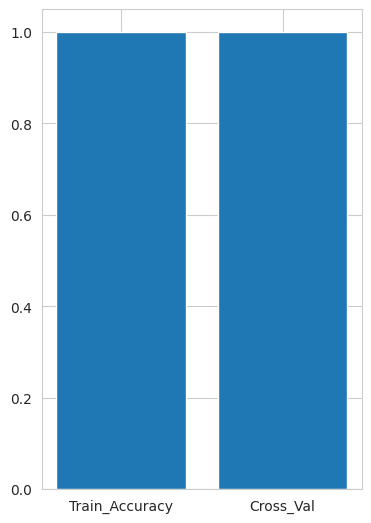

In [ ]:
Train_acc = LR.score(X_train, y_train)

fig = plt.figure()
ax = fig.add_axes([0,0,0.5,1])
langs = ['Train_Accuracy', 'Cross_Val']
students = [Train_acc,score_mean]
ax.bar(langs,students)
plt.show()

**Insight**

From the cross-validation, it is evident that the cross validation data performs the same as the training accuracy. This might be good or an indicator that is may have overfitted.

# 9.2.2 Cross Validation for RFC



In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rfc, X, y, cv=10) # Data is set to be split into 10 segments with 10 iterations
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
score_mean = scores.mean()
score_mean

np.float64(1.0)

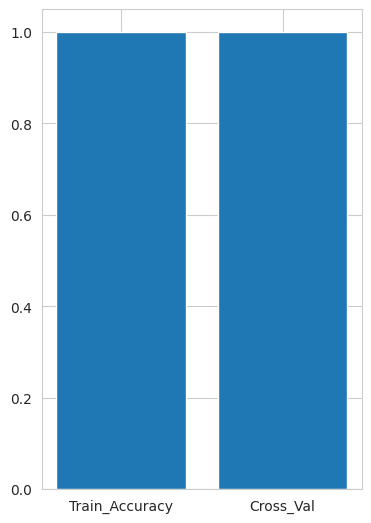

In [ ]:
Train_acc = rfc.score(X_train, y_train)

fig = plt.figure()
ax = fig.add_axes([0,0,0.5,1])
langs = ['Train_Accuracy', 'Cross_Val']
students = [Train_acc,score_mean]
ax.bar(langs,students)
plt.show()

**Insight**

From the cross-validation, it is evident that the cross validation data performs the same as the training accuracy. This might be good or an indicator that is may have overfitted.

# 10.1 Split Training and Testing Data (Failure Type Output Parameter)

In [ ]:
# Extracts the Quality_type column to create a y dataframe
y = df["Failure Type"]

# Extract the other columns from the dataset to create an X dataframe
X = df.drop(["Product ID", 'Type'], axis=1)

# One-hot encode the 'Type' column
X = pd.get_dummies(X, columns=['Failure Type'], drop_first=True)

# Split X and y vectors into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20, #Training 80% and Testing 20%
                                                    random_state=2)

print ("X_train:", X_train.shape)
print ("X_test:", X_test.shape)
print ("y_train:", y_train.shape)
print ("y_test:", y_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)


In [ ]:
# Import LR Library
from sklearn.linear_model import LogisticRegression


# Train the Model
LR = LogisticRegression(C=1.0, class_weight= 'balanced', dual=False, fit_intercept=True,
                 intercept_scaling=1, l1_ratio=None, max_iter=100, n_jobs=None,
                 penalty='l2', random_state=None, solver='lbfgs', tol=0.0001,
                 verbose=0, warm_start=False)

LR1 = LogisticRegression(C=0.8, class_weight='balanced', dual=False, fit_intercept=True,
                 intercept_scaling=1, l1_ratio=None, max_iter=100, n_jobs=None,
                 penalty='l2', random_state=None, solver='lbfgs', tol=0.0001,
                 verbose=0, warm_start=False)

LR2 = LogisticRegression(C=0.6, class_weight='balanced', dual=False, fit_intercept=True,
                 intercept_scaling=1, l1_ratio=None, max_iter=100, n_jobs=None,
                 penalty='l2', random_state=None, solver='lbfgs', tol=0.0001,
                 verbose=0, warm_start=False)

# solver = lbfgs  is the default and handles multinominal loss
# meaning, it can consider every features versus the target

LR.fit(X_train, y_train)
LR1.fit(X_train, y_train)
LR2.fit(X_train, y_train)

LogisticRegression(C=0.6, class_weight='balanced')

In [ ]:
# Import Library
from sklearn.ensemble import RandomForestClassifier

# Setup RFC Model
rfc = RandomForestClassifier(criterion='gini', max_leaf_nodes=None) # Parameters left empty to use its default values

# Launch Random Forest training
rfc.fit(X_train, y_train)

RandomForestClassifier()

# 10.2 Hyperparameter Tuning via GridSearchCV For Failure Type

In [ ]:
import warnings
from sklearn.model_selection import GridSearchCV

# Mute all warnings
warnings.filterwarnings("ignore")


param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
}

# Create the Logistic Regression model
model = LogisticRegression()

# Create the GridSearchCV object with the model and parameter grid
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the model to the data and perform grid search
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate the best model on the test data
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test set accuracy with best model:", test_score)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters: {'C': 0.1, 'penalty': 'l2'}
Best cross-validation score: 0.968375
Test set accuracy with best model: 0.9625


**Insight**

The hyperparameters of C=0.1 shows the best results as shown in the code above.


In [ ]:
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Mute all warnings
warnings.filterwarnings("ignore")

# Define the hyperparameters and their possible values for Random Forest Classifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Create the Random Forest Classifier model instance
model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility

# Create the GridSearchCV object with the model and parameter grid
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the model to the data and perform grid search
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate the best model on the test data
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test set accuracy with best model:", test_score)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best cross-validation score: 1.0
Test set accuracy with best model: 1.0


**Insight**

The hyperparameters of max_depth = none, min_samples_leaf = 1, and n_estimatos = 100 shows the best results as shown in the code above.

# 10.3 Basic Model Evaluation For Failure Type

In [ ]:
# Evaluates the performance on the Training Set

#Compare Score
print ("Accuracy Score of Training Set:")

# Print out all models' accuracy score for training set
print("LR:",LR.score(X_train, y_train))
print("RFC:",rfc.score(X_train, y_train))

Accuracy Score of Training Set:
LR: 1.0
RFC: 1.0


**Insight**

It can be seen that the model reaches 100% accuracy on training datasets for random forest classifier and 55.1% accuracy for logistical regression.

For random forest classifier, it might be good but it may also indicate "overfitting" as the training data is being used for testing and when given the same data, it can predict it with the exact value. Hence the 100% accuracy. So, model may not perform as well in terms of accuracy on unseen data as compared.

In [ ]:
# Evaluates the performance on the Test Set

#Compare Score
print ("Accuracy Score of Testing Set:")

# Print out all models' accuracy score for training set
print("LR:",LR.score(X_test, y_test))
print("RFC:",rfc.score(X_test, y_test))

Accuracy Score of Testing Set:
LR: 1.0
RFC: 1.0


**Insight**

The model performs the same accuracy at 100% as the training set for random forest classifier, this may indicate overfitting. This might be due to unbalanced data. While for logistical regression, the model performs slightly better on the test set than the training set, so the model is likely normal.

# 10.4 Identifying Overfitting and Underfitting For Failure Type

# 10.4.1 Cross Validation for LR

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LR, X, y, cv=10) # I set the data to be split into 10 segments with 10 iterations
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
score_mean = scores.mean()
score_mean

np.float64(1.0)

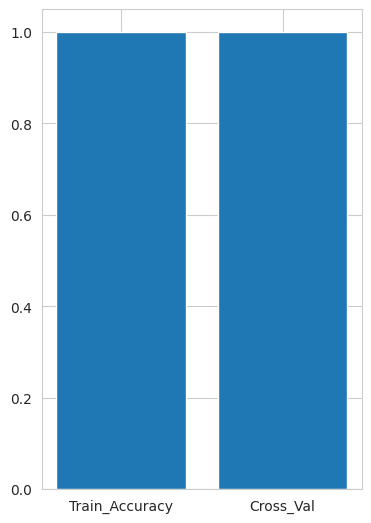

In [ ]:
Train_acc = LR.score(X_train, y_train)

fig = plt.figure()
ax = fig.add_axes([0,0,0.5,1])
langs = ['Train_Accuracy', 'Cross_Val']
students = [Train_acc,score_mean]
ax.bar(langs,students)
plt.show()

**Insight**

From the cross-validation, it is evident that the cross validation data performs better than the training accuracy. This might be good as it suggests that the model generalises well to new data.

# 10.4.2 Cross Validation for RFC

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rfc, X, y, cv=10) # I set the data to be split into 10 segments with 10 iterations
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
score_mean = scores.mean()
score_mean

np.float64(1.0)

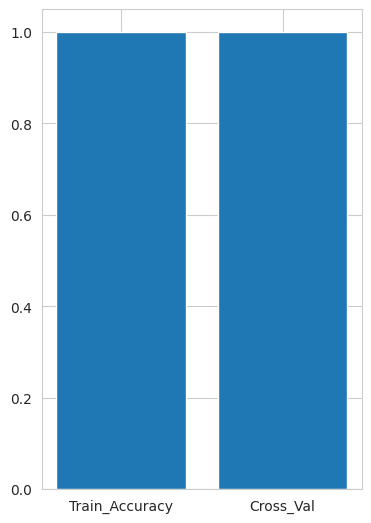

In [ ]:
Train_acc = rfc.score(X_train, y_train)

fig = plt.figure()
ax = fig.add_axes([0,0,0.5,1])
langs = ['Train_Accuracy', 'Cross_Val']
students = [Train_acc,score_mean]
ax.bar(langs,students)
plt.show()

**Insight**

From the cross-validation, it is evident that the cross validation data performs the same as the training accuracy. This might be good or an indicator that is may have overfitted.